In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [24]:
device = torch.device('cpu')

In [4]:
data_dir = '/content/dataset'

In [5]:
transform =  transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [18]:
dataset =  ImageFolder(data_dir, transform=transform)

dataloader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [19]:
len(dataset)

500

In [20]:
def add_noise(images, noise_factor=0.3):
  noisy = images + noise_factor * torch.randn_like(images)
  noisy = torch.clip(noisy, 0., 1.)
  return noisy

In [26]:
class Denoising_Autoencoder(nn.Module):

  def __init__(self):
    super(Denoising_Autoencoder, self).__init__()

    self.encode = nn.Sequential(
        nn.Conv2d(3, 32, 3, stride=2, padding=1),
        nn.ReLU(),

        nn.Conv2d(32, 64, 3, stride=2, padding=1),
        nn.ReLU(),

        nn.Conv2d(64, 128, 3, stride=2, padding=1),
        nn.ReLU()
    )

    self.decode = nn.Sequential(
        nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
        nn.ReLU(),

        nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
        nn.ReLU(),

        nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
        nn.Sigmoid()
    )

  def forward(self, x):
    encoded = self.encode(x)
    decoded = self.decode(encoded)
    return decoded

In [27]:
model =  Denoising_Autoencoder().to('cpu')

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [29]:
num_epochs = 20
loss_history = []

for epoch in range(num_epochs):
  epoch_loss = 0

  for images, _ in dataloader:
    images = images.to('cpu')

    noisy_images =  add_noise(images).to(device)

    outputs = model(noisy_images)

    loss = criterion(outputs, images)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

  avg_loss = epoch_loss / len(dataloader)
  loss_history.append(avg_loss)

  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 0.1029
Epoch [2/20], Loss: 0.1025
Epoch [3/20], Loss: 0.1021
Epoch [4/20], Loss: 0.1019
Epoch [5/20], Loss: 0.1021
Epoch [6/20], Loss: 0.1023
Epoch [7/20], Loss: 0.1022
Epoch [8/20], Loss: 0.1022
Epoch [9/20], Loss: 0.1019
Epoch [10/20], Loss: 0.1022
Epoch [11/20], Loss: 0.1023
Epoch [12/20], Loss: 0.1018
Epoch [13/20], Loss: 0.1023
Epoch [14/20], Loss: 0.1021
Epoch [15/20], Loss: 0.1023
Epoch [16/20], Loss: 0.1025
Epoch [17/20], Loss: 0.1021
Epoch [18/20], Loss: 0.1023
Epoch [19/20], Loss: 0.1022
Epoch [20/20], Loss: 0.1021


Text(0.5, 1.0, 'Training Loss')

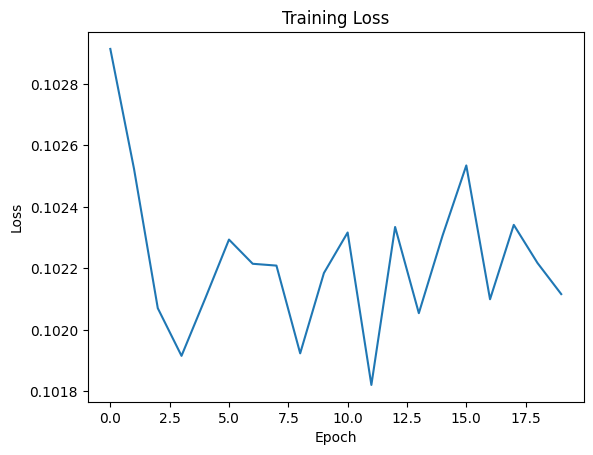

In [30]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

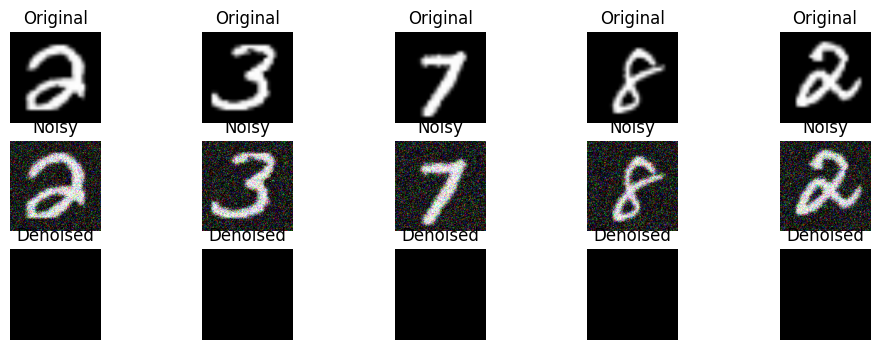

In [31]:
dataiter = iter(dataloader)
images, _ = next(dataiter)

images = images.to(device)
noisy_images = add_noise(images).to(device)

outputs = model(noisy_images)

images = images.cpu().detach()
noisy_images = noisy_images.cpu().detach()
outputs = outputs.cpu().detach()

plt.figure(figsize=(12,4))

for i in range(5):

    # Original
    ax = plt.subplot(3,5,i+1)
    plt.imshow(np.transpose(images[i], (1,2,0)))
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3,5,i+6)
    plt.imshow(np.transpose(noisy_images[i], (1,2,0)))
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3,5,i+11)
    plt.imshow(np.transpose(outputs[i], (1,2,0)))
    plt.title("Denoised")
    plt.axis("off")

plt.show()